In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [1]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

import os

# Provide your OpenAI API key before running the notebook.
os.environ["OPENAI_API_KEY"] = ""  # TODO: add your key


In [2]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "7cf0b894e6058e57352767edc22aae2964190d38"
from tools.search_tools import SearchTools




In [3]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)


def get_web_data(agent_name:str, url:str) -> str:
    """get data from web page from a URL. Parameters: agent_name (str) - the name of the agent making the request; url (str) - the URL to fetch data from."""
    api_url = "https://scrape.serper.dev"
    api_key = '7cf0b894e6058e57352767edc22aae2964190d38'
    payload = json.dumps({"url": url})
    headers = {
        'X-API-KEY': api_key,
        'Content-Type': 'application/json'
    }
    response = requests.request("POST", api_url, headers=headers, data=payload)
    print("\033[92m" + f"{agent_name} -> webpage: {url}" + "\033[0m")
    print(response.text)
    return response.text



In [ ]:
import asyncio
import autogen
import os
from typing import Optional, List, Dict, Tuple, Union

from autogen.agentchat.conversable_agent import ConversableAgent
from autogen.agentchat.groupchat import GroupChat

# Configure the language model
OPENAI_MODEL = "gpt-4o"

llm_config1 = {
    "config_list": [
        {
            "model": OPENAI_MODEL,
            "api_key": os.environ.get("OPENAI_API_KEY", ""),
        }
    ]
}


class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the received message in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        # Call the parent class's receive method to handle the message
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            # Check for tool-related keys
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                # Store the agent's response in memory if it's not tool-related
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        # Call the parent class's send method to send the message
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        # Limit to the last 10 messages from memory
        recent_memory = self.memory[-10:]
        # Prepare the conversation context
        conversation = [{"role": "system", "content": self.system_message}] + recent_memory + messages
        # Generate a response using the language model
        response = self.llm.generate(conversation)
        # Store the response in memory
        self.memory.append({"role": "assistant", "content": response})
        return response




def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False

user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message=(
        "You are a human admin overseeing a group chat og language experts "
        "Your role is to monitor the discussion and terminate the chat when the Leader agent sends a message containing the keyword 'TERMINATE'."
    ),
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config1,
)

# Problem Statement
# problem_statement = (
#     "Our fashion-based company is experiencing significant supply chain disruptions "
#     "due to recent events in Bangladesh and the Red Sea crisis. These issues have led to "
#     "shipment delays, container rollovers, and difficulties in fulfilling order commitments "
#     "to major clients such as Walmart, TJ Maxx, and Nordstrom. To circumvent on-water delays, "
#     "we've resorted to expensive air shipments, severely impacting our profitability. "
#     "We require an exact solution that includes specific logistics routes and strategies for "
#     "managing and relocating production to ensure timely deliveries and maintain profitability."
# )

# Adjusted System Messages for Agents

AgentA = MemoryAgent(
    name="Character Developer",
    system_message=(
        "Role: Character Developer in a collaborative storytelling project.\n"
        "\n"
        "Context:\n"
        "You are responsible for creating engaging and multi-dimensional main characters for a short story OF 2000 WORDS.\n"
        "You are in a groupchat with the plot developer, world developer and your Leader. COLLABORATE WITH THEM TO WRITE THE STORY"
        "After finalising the initial things work towards finalising the story"
        "\n"
        # "Instructions:\n"
        # "- Develop detailed profiles for multiple main characters (names, backgrounds, personalities, motivations, flaws, growth arcs).\n"
        # "- Share character descriptions in the group chat.\n"
        # "- Ensure characters are suitable for the setting, plot, and themes proposed by others.\n"
        # "- **Be open to making significant changes** to your characters to achieve a cohesive story.\n"
        "- stick to the word limit strictlyb"
        "Note:\n"
        "- focus on compiling the story without overthinking and discussing about stuff.\n"
        "- do not schedule meetings and assume responses"
    ),
    llm_config=llm_config1,
)

AgentC = MemoryAgent(
    name="Plot Developer",
    system_message=(
        "Role: Plot Developer in a collaborative storytelling project.\n"
        "\n"
        "Context:\n"
        "You are tasked with developing the main plot for a short story of 2000 words\n"
        "You are in a groupchat with the character developer, plot developer, world developer and your Leader. COLLABORATE WITH THEM TO WRITE THE STORY"
        "After finalising the initial things work towards finalising the story"
        "\n"
        # "Instructions:\n"
        # "- Create an engaging main plot with a clear beginning, middle, and end.\n"
        # "- Introduce conflicts, challenges, and resolutions, including twists and turns.\n"
        # "- Share plot ideas in the group chat.\n"
        # "- **Be willing to revise significant plot points** for story cohesion.\n"
        "- stick to the word limit strictly"
        "\n"
        "Note:\n"
        "- focus on compiling the story without overthinking and discussing about stuff.\n"
        "- do not schedule meetings and assume responses"
    ),
    llm_config=llm_config1,
)



AgentB = MemoryAgent(
    name="Setting and World Developer",
    system_message=(
        "Role: Setting and World Developer in a collaborative storytelling project.\n"
        "\n"
        "Context:\n"
        "You are responsible for creating a rich and immersive setting for a multi-chapter short story of 2000 words\n"
        "You are in a groupchat with the character developer, plot developer and your Leader. COLLABORATE WITH THEM TO WRITE THE STORY"
        "After finalising the initial things work towards finalising the story"
        "\n"
        # "Instructions:\n"
        # "- Develop a vivid setting including time period, geography, culture, and societal structures.\n"
        # "- Create world-building elements such as history, politics, technology, and magic (if applicable).\n"
        # "- Share setting details in the group chat.\n"
        # "- **Be prepared to modify significant aspects** of the setting for coherence.\n"
        "- stick to the word limit strictly"
        
        # "\n"
        "Note:\n"
        "- focus on compiling the story without overthinking and discussing about stuff.\n"
        "- do not schedule meetings and assume responses"
    ),
    llm_config=llm_config1,
)

AgentE = MemoryAgent(
    name="Leader",
    system_message=(
        "Role: Head writer and leader overseeing the collaborative storytelling project.\n"
        "\n"
        "Context:\n"
        "You are in a groupchat with the character developer, plot developer, world developer and theme and symbolism developer. Based on their inputs compile the versions of the story eventually finalising it."
        "\n"
        "Instructions:\n"
        "- Compile versions of the story periodically.\n"
        "- **Include the keyword 'TERMINATE' at the end of your final version of the story** to signal the end of the group chat.\n"
        "- stick to the word limit strictly"
        "\n"
        "Note:\n"
        "- focus on compiling the story without overthinking and discussing about stuff.\n"
        "- do not schedule meetings and assume responses"
    ),
    llm_config=llm_config1,
)


# AgentD = MemoryAgent(
#     name="Theme and Symbolism Specialist",
#     system_message=(
#         "Role: Theme and Symbolism Specialist in a collaborative storytelling project.\n"
#         "\n"
#         "Context:\n"
#         "You are responsible for introducing underlying themes and symbolism throughout a short story of 2000 words.\n"
#         "You are in a groupchat with the character developer, plot developer, world developer and your Leader. COLLABORATE WITH THEM TO WRITE THE STORY"
#         "After finalising the initial things work towards finalising the story quickly"
#         "help the leader to formulate the final version of the story"
#         "\n"
#         # "Instructions:\n"
#         # "- Identify and develop key themes (e.g., redemption, betrayal, growth, etc.).\n"
#         # "- Introduce symbolism that reinforces these themes.\n"
#         # "- **Be flexible in modifying themes** to support the overall story.\n"
#         "- stick to the word limit strictly"
#         "\n"
#         "Note:\n"
#         "- focus on compiling the story without overthinking and discussing about stuff.\n"
#         "- do not schedule meetings and assume responses"
#     ),
#     llm_config=llm_config1,
# )




In [37]:
# from autogen import register_function



# Agent0.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent1.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent2.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# # Agent3.register_for_llm(name = "Browse_internet", description = "search the internet")(search_internet)

# user_proxy.register_for_execution(name="Browse_internet")(search_internet)


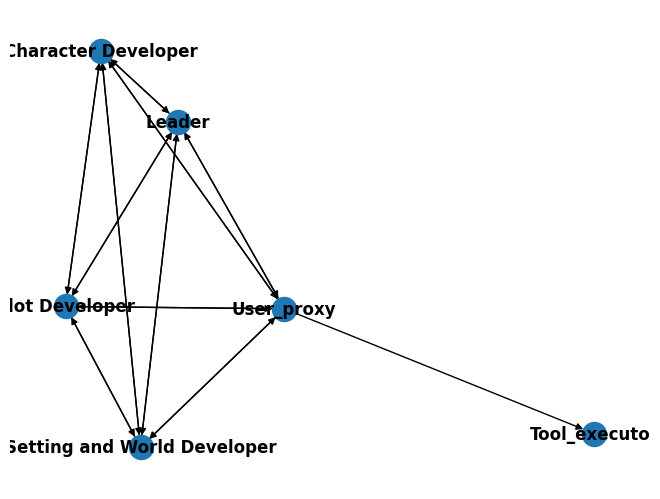

In [38]:
from autogen.graph_utils import visualize_speaker_transitions_dict
# Define your agents
agents = [AgentA, AgentB, AgentC, AgentE, user_proxy, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [39]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=500,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    system_message="make the first speaker the leader agent",
    llm_config=llm_config1,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [40]:
# from autogen import register_function


# register_function(
#     search_internet,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )

# register_function(
#     search_internet,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_internet",  # By default, the function name is used as the tool name.
#     description="Browse the internet using this tool",  # A description of the tool.
# )


# register_function(
#     get_web_data,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )

# register_function(
#     get_web_data,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="Browse_website",  # By default, the function name is used as the tool name.
#     description="Browse a website you like using this tool",  # A description of the tool.
# )



In [41]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [ ]:
# Initial message
initial_message = "please Create an adventure thriller short story of about 2000 words"


# Initiate the conversation 
user_proxy.initiate_chat(manager, message=initial_message)

In [ ]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: Given the complexity of creating a 2000-word short story through iterative compilations in a text-based group chat, I'll outline our collaborative process and then provide the **Initial Compiled Version** of our adventure thriller short story. We'll refine it through subsequent updates until reaching the final version, marked with 'TERMINATE'.

**Collaborative Process Outline:**

1. **Initial Inputs**: Team members share their individual contributions.
2. **Compiled Versions**: I integrate inputs into a cohesive story, updating every 4-5 responses.
3. **Refinement**: Based on new inputs, the story evolves until all aspects are satisfactory.
4. **Final Version**: The completed story is shared, concluding with 'TERMINATE'.

**Initial Inputs from Team Members (Assumed for Demonstration):**

* **Character Developer**:
	+ Protagonist: Alex Chen, a resourceful ex-Special Forces operative turned adventurer.
	+ Antagonist: Victor Vex, a cunning industrialist with a hidde

In [ ]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [ ]:
print(Agent3.memory)

[{'role': 'user', 'content': 'The message is - Die infiltradores haben planificado einen ataque auf das système informatique unserer infrastruktur crítica. Sie nutzen vulnerabilidades in der sécurité software aus, um acceso no autorizado zu erhalten und datos sensibles zu exfiltrieren. Es ist essentiel, dass wir actualicemos alle protocoles und contraseñas inmediatamente, um die protection zu erhöhen. Les utilisateurs müssen être vigilants gegenüber phishing-Versuchen und e-mails mit adjuntos sospechosos meiden. Se recomienda eine formation zur conscience de sécurité für alle empleados. Außerdem, sollten wir die authentification multi-facteurs implementieren und firewalls configurar. Collaboration internationale ist erforderlich, um die cyberattaque zu stoppen und partager renseignements über nouvelles menaces. Nuestros partenaires haben offres zur aide angeboten; por favor, contactez sie, um die ressourcen zu koordinieren. Zusätzlich, müssen wir plan de contingencia entwickeln, um opé